# Special Experiment Visualizations

This notebook reproduces the plotting style from `analysis.ipynb` for the newly added special experiments only.

It includes:
- runtime curves with 2 x 3 lines
- peak memory curves with 2 x 3 lines
- one ADMIXTURE K-value figure with 3 lines
- one fastSTRUCTURE K-value figure with 3 lines

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

repo = Path.cwd()

EXPERIMENTS = [
    {
        "name": "chr20_maf001_pruned",
        "label": "Chr20 MAF=0.01 + LD prune",
        "color": "#1f77b4",
        "admixture_dir": repo / "dump/special_chr20_maf001_pruned/admixture",
        "structure_dir": repo / "dump/special_chr20_maf001_pruned/structure",
        "structure_prefix": "structure_chr20_maf001_pruned",
    },
    {
        "name": "chr20_maf005_pruned",
        "label": "Chr20 MAF=0.05 + LD prune",
        "color": "#ff7f0e",
        "admixture_dir": repo / "dump/special_chr20_maf005_pruned/admixture",
        "structure_dir": repo / "dump/special_chr20_maf005_pruned/structure",
        "structure_prefix": "structure_chr20_maf005_pruned",
    },
    {
        "name": "chr20_maf001_no_ld",
        "label": "Chr20 MAF=0.01 without LD prune",
        "color": "#9467bd",
        "admixture_dir": repo / "dump/special_chr20_maf001_no_ld/admixture",
        "structure_dir": repo / "dump/special_chr20_maf001_no_ld/structure",
        "structure_prefix": "structure_chr20_maf001_no_ld",
    },
]

METHOD_LABELS = {
    "admixture": "ADMIXTURE",
    "faststructure": "fastSTRUCTURE",
}
METHOD_LINESTYLES = {
    "ADMIXTURE": "-",
    "fastSTRUCTURE": "--",
}
ALL_K_VALUES = list(range(2, 11))


def has_method_output(experiment: dict, method_name: str, k_value: int) -> bool:
    if method_name == "admixture":
        q_pattern = f"*.{k_value}.Q"
        return any(experiment["admixture_dir"].glob(q_pattern))
    if method_name == "faststructure":
        meanq_path = (
            experiment["structure_dir"]
            / f"{experiment['structure_prefix']}_ALL"
            / f"fS_run_K.{k_value}.meanQ"
        )
        return meanq_path.exists()
    raise ValueError(f"Unsupported method: {method_name}")



def load_fit_metrics(experiment: dict) -> pd.DataFrame:
    frames = []
    metric_paths = {
        "admixture": experiment["admixture_dir"] / "metrics.tsv",
        "faststructure": experiment["structure_dir"] / "metrics.tsv",
    }
    for method_name, metric_path in metric_paths.items():
        frame = pd.read_csv(metric_path, sep="\t")
        frame = frame[frame["step"] == "fit"].copy()
        frame["K_num"] = pd.to_numeric(frame["K"], errors="coerce")
        frame = frame.dropna(subset=["K_num"])
        frame["K_num"] = frame["K_num"].astype(int)
        for column in ["elapsed_sec", "user_cpu_sec", "sys_cpu_sec", "max_rss_kb", "exit_code"]:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
        frame["max_rss_mb"] = frame["max_rss_kb"] / 1024
        frame["data_available"] = frame["K_num"].map(lambda k_value: has_method_output(experiment, method_name, k_value))
        frame["experiment"] = experiment["name"]
        frame["experiment_label"] = experiment["label"]
        frame["method_label"] = METHOD_LABELS[method_name]
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


fit_metrics = pd.concat([load_fit_metrics(experiment) for experiment in EXPERIMENTS], ignore_index=True)
fit_metrics_ok = fit_metrics[fit_metrics["data_available"]].copy()

summary = (
    fit_metrics_ok.groupby(["experiment_label", "method_label"])
    .agg(
        successful_runs=("K_num", "count"),
        min_k=("K_num", "min"),
        max_k=("K_num", "max"),
        mean_elapsed_sec=("elapsed_sec", "mean"),
        peak_rss_mb=("max_rss_mb", "max"),
    )
    .round(3)
)
summary

successful_runs  min_k  max_k  \
experiment_label                method_label                                   
Chr20 MAF=0.01 + LD prune       ADMIXTURE                    9      2     10   
                                fastSTRUCTURE                8      3     10   
Chr20 MAF=0.01 without LD prune ADMIXTURE                    9      2     10   
                                fastSTRUCTURE                9      2     10   
Chr20 MAF=0.05 + LD prune       ADMIXTURE                    9      2     10   
                                fastSTRUCTURE                9      2     10   

                                               mean_elapsed_sec  peak_rss_mb  
experiment_label                method_label                                  
Chr20 MAF=0.01 + LD prune       ADMIXTURE               801.778      233.910  
                                fastSTRUCTURE           874.125      424.363  
Chr20 MAF=0.01 without LD prune ADMIXTURE              6997.778     1885.766  
                                fastSTRUCTURE          6079.333     1292.633  
Chr20 MAF=0.05 + LD prune       ADMIXTURE               137.333       50.320  
                                fastSTRUCTURE           416.667      425.379

## Time and Space Complexity

The two plots below follow the structure of the corresponding section in `analysis.ipynb`, but only for the three special experiments. Each subplot contains 2 x 3 curves: two methods across three experimental settings.

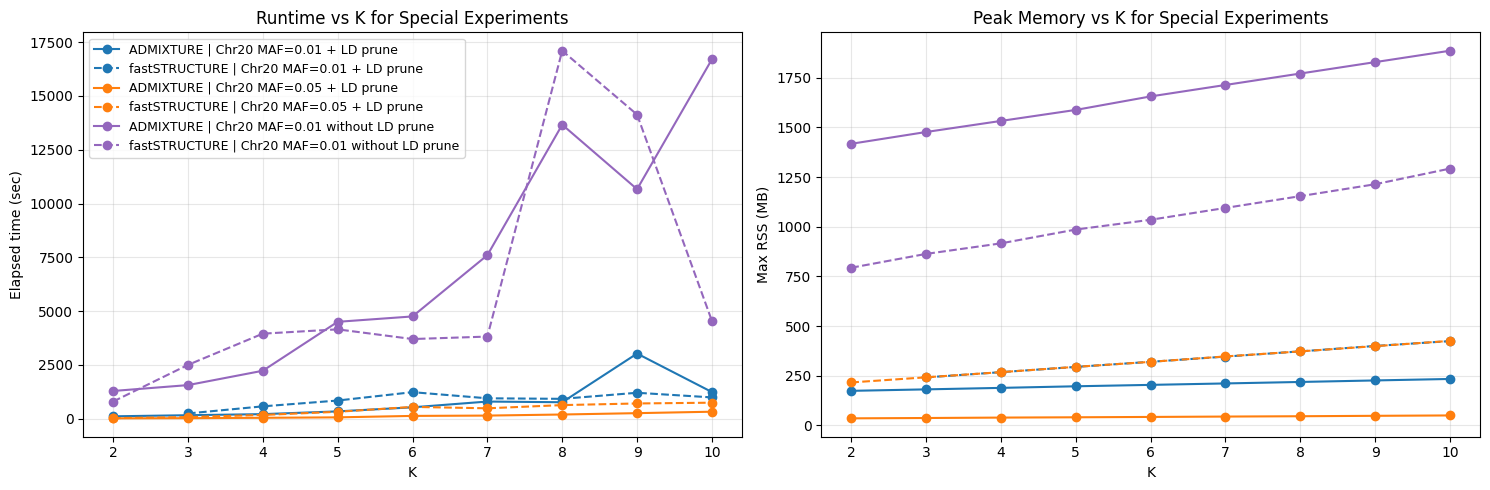

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for experiment in EXPERIMENTS:
    for method_label in ["ADMIXTURE", "fastSTRUCTURE"]:
        group = fit_metrics_ok[
            (fit_metrics_ok["experiment"] == experiment["name"])
            & (fit_metrics_ok["method_label"] == method_label)
        ].sort_values("K_num")
        if group.empty:
            continue
        aligned = (
            group[["K_num", "elapsed_sec", "max_rss_mb"]]
            .drop_duplicates(subset="K_num", keep="last")
            .set_index("K_num")
            .reindex(ALL_K_VALUES)
        )
        curve_label = f"{method_label} | {experiment['label']}"
        axes[0].plot(
            aligned.index,
            aligned["elapsed_sec"],
            marker="o",
            linestyle=METHOD_LINESTYLES[method_label],
            color=experiment["color"],
            label=curve_label,
        )
        axes[1].plot(
            aligned.index,
            aligned["max_rss_mb"],
            marker="o",
            linestyle=METHOD_LINESTYLES[method_label],
            color=experiment["color"],
            label=curve_label,
        )

axes[0].set_title("Runtime vs K for Special Experiments")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Elapsed time (sec)")
axes[0].set_xticks(ALL_K_VALUES)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Peak Memory vs K for Special Experiments")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Max RSS (MB)")
axes[1].set_xticks(ALL_K_VALUES)
axes[1].grid(True, alpha=0.3)

axes[0].legend(fontsize=9)

plt.tight_layout()
plt.show()

## K-value Results and Interpretation

The next two figures mirror the K-value plotting idea from `analysis.ipynb`, split by method. Each method gets one figure with three curves, one per special experiment.

In [3]:
def load_admixture_cv(experiment: dict) -> pd.DataFrame:
    cv_path = experiment["admixture_dir"] / "cv_results.txt"
    pairs = []
    for line in cv_path.read_text().strip().splitlines():
        k_str, cv_str = line.split()
        pairs.append((int(k_str), float(cv_str)))
    frame = pd.DataFrame(pairs, columns=["K", "score"])
    frame["experiment"] = experiment["name"]
    frame["experiment_label"] = experiment["label"]
    return frame.sort_values("K")


admix_k_metrics = pd.concat([load_admixture_cv(experiment) for experiment in EXPERIMENTS], ignore_index=True)
admix_k_metrics.head()

,K,score,experiment,experiment_label
0,2,0.22724,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune
1,3,0.21620,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune
2,4,0.21287,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune
3,5,0.21026,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune
4,6,0.21319,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune


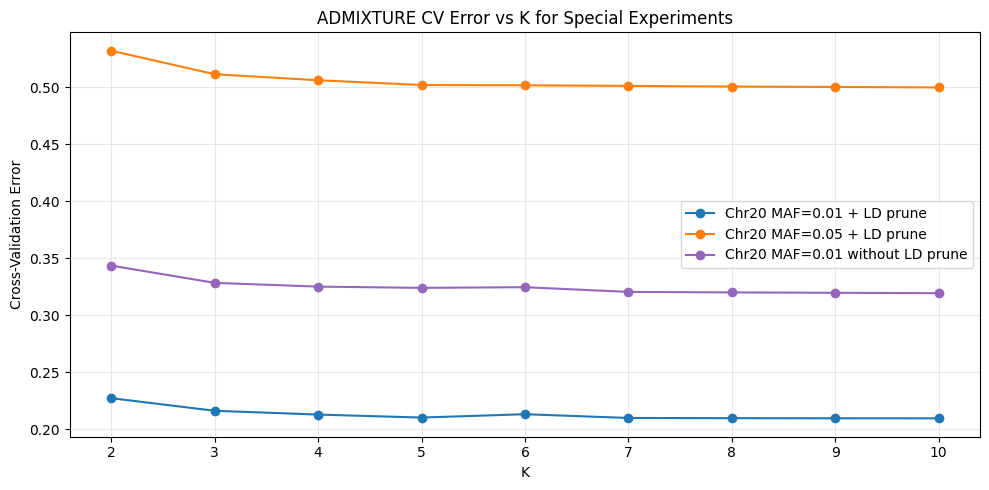

In [4]:
plt.figure(figsize=(10, 5))
for experiment in EXPERIMENTS:
    group = admix_k_metrics[admix_k_metrics["experiment"] == experiment["name"]].sort_values("K")
    aligned = group.drop_duplicates(subset="K", keep="last").set_index("K").reindex(ALL_K_VALUES)
    plt.plot(aligned.index, aligned["score"], marker="o", color=experiment["color"], label=experiment["label"])

plt.title("ADMIXTURE CV Error vs K for Special Experiments")
plt.xlabel("K")
plt.ylabel("Cross-Validation Error")
plt.xticks(ALL_K_VALUES)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
def extract_marginal_likelihood(log_path: Path) -> float:
    match = re.search(
        r"Marginal Likelihood =\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)",
        log_path.read_text(),
    )
    if match is None:
        raise ValueError(f"Cannot find marginal likelihood in {log_path}")
    return float(match.group(1))



def load_faststructure_ml(experiment: dict) -> pd.DataFrame:
    result_dir = experiment["structure_dir"] / f"{experiment['structure_prefix']}_ALL"
    rows = []
    for meanq_path in sorted(result_dir.glob("fS_run_K.*.meanQ")):
        match = re.search(r"K\.([0-9]+)\.meanQ$", meanq_path.name)
        if match is None:
            continue
        k_value = int(match.group(1))
        log_path = result_dir / f"fS_run_K.{k_value}.log"
        rows.append(
            {
                "K": k_value,
                "score": extract_marginal_likelihood(log_path),
                "experiment": experiment["name"],
                "experiment_label": experiment["label"],
            }
        )
    return pd.DataFrame(rows).sort_values("K")


faststructure_k_metrics = pd.concat(
    [load_faststructure_ml(experiment) for experiment in EXPERIMENTS],
    ignore_index=True,
)
faststructure_k_metrics.head()

,K,score,experiment,experiment_label
0,2,-0.388788,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune
1,3,-0.379798,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune
2,4,-0.378239,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune
3,5,-0.377155,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune
4,6,-0.376978,chr20_maf001_pruned,Chr20 MAF=0.01 + LD prune


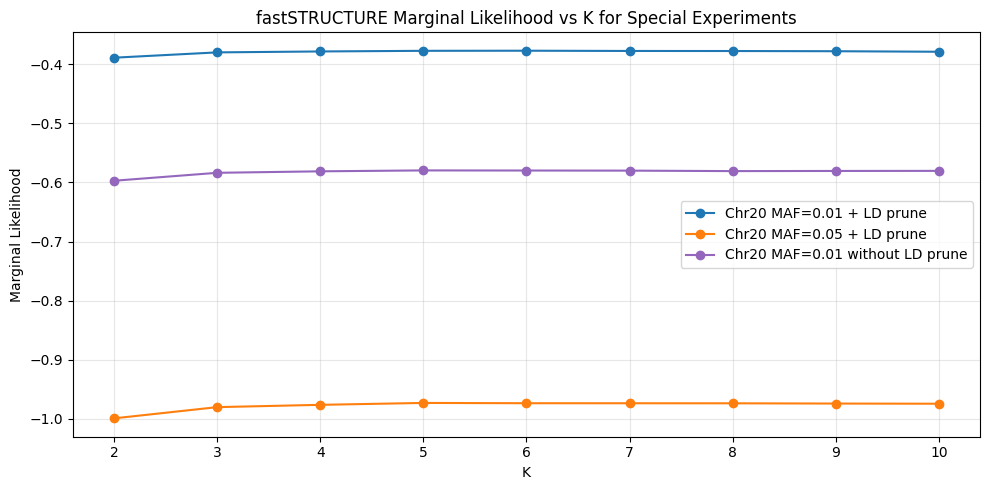

In [6]:
plt.figure(figsize=(10, 5))
for experiment in EXPERIMENTS:
    group = faststructure_k_metrics[faststructure_k_metrics["experiment"] == experiment["name"]].sort_values("K")
    aligned = group.drop_duplicates(subset="K", keep="last").set_index("K").reindex(ALL_K_VALUES)
    plt.plot(aligned.index, aligned["score"], marker="o", color=experiment["color"], label=experiment["label"])

plt.title("fastSTRUCTURE Marginal Likelihood vs K for Special Experiments")
plt.xlabel("K")
plt.ylabel("Marginal Likelihood")
plt.xticks(ALL_K_VALUES)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()